Dataset Loaded Successfully ✅
Shape: (1048575, 21)

Available Columns:

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='object')

Death Column Created Successfully ✅
DEATH
0    971633
1     76942
Name: count, dtype: int64


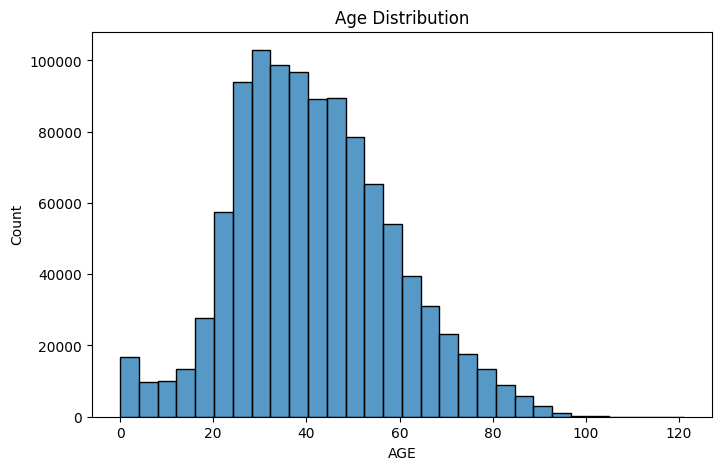

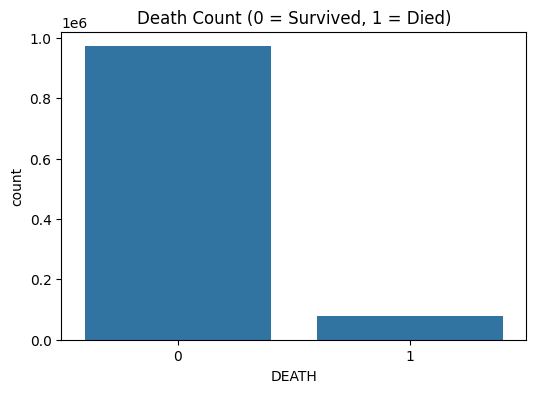

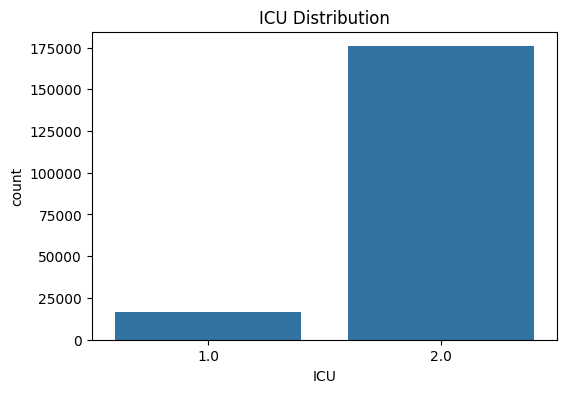

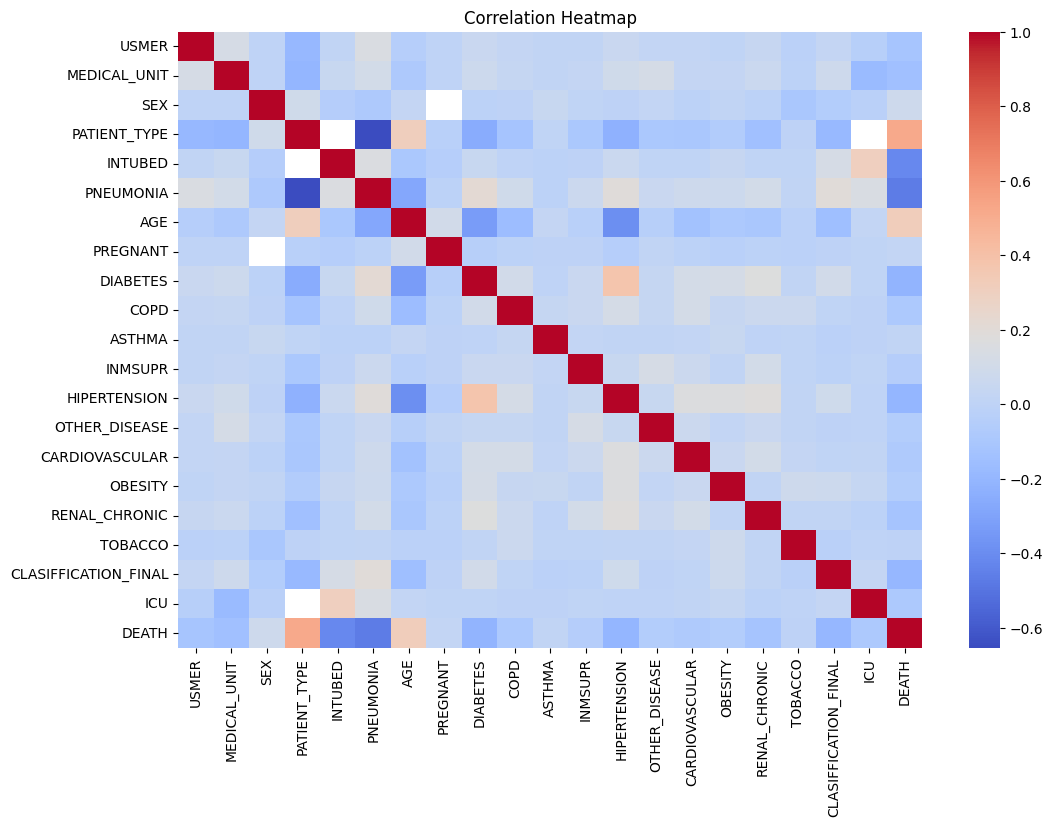


🎯 Project Completed Successfully Without Errors!


In [7]:
# =====================================================
# COVID-19 Patient Data Analysis 
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Load Dataset
# =========================

file_path = '/kaggle/input/datasets/meirnizri/covid19-dataset/Covid Data.csv'
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")
print("Shape:", df.shape)

# Clean column names
df.columns = df.columns.str.strip().str.upper()

print("\nAvailable Columns:\n")
print(df.columns)

# =========================
# 2. Basic Cleaning
# =========================

df.replace([97, 98, 99], np.nan, inplace=True)

# =========================
# 3. Create Death Column SAFELY
# =========================

if 'DATE_DIED' in df.columns:
    
    # Convert to string to avoid issues
    df['DATE_DIED'] = df['DATE_DIED'].astype(str)
    
    # If date is 9999-99-99 → survived
    df['DEATH'] = df['DATE_DIED'].apply(
        lambda x: 0 if '9999' in x else 1
    )
    
    print("\nDeath Column Created Successfully ✅")
    print(df['DEATH'].value_counts())

else:
    print("\n⚠ DATE_DIED column not found.")
    df['DEATH'] = np.nan

# =========================
# 4. Age Distribution
# =========================

if 'AGE' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['AGE'], bins=30)
    plt.title("Age Distribution")
    plt.show()

# =========================
# 5. Death Analysis
# =========================

if 'DEATH' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='DEATH', data=df)
    plt.title("Death Count (0 = Survived, 1 = Died)")
    plt.show()

# =========================
# 6. ICU Analysis
# =========================

if 'ICU' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='ICU', data=df)
    plt.title("ICU Distribution")
    plt.show()

# =========================
# 7. Correlation Heatmap
# =========================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\n🎯 Project Completed Successfully Without Errors!")
